# K-Means Clustering


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Data Clean

In [14]:
customers = pd.read_csv("retail_customers.csv")

customers.head()
print(customers.isnull().sum())
print(customers.duplicated().sum())

print(f"Rows, Columns {customers.shape}")

customer_id            0
age                    0
annual_income          0
visits_last_year       0
avg_order_value        0
days_since_purchase    0
online_order_share     0
promo_emails_opened    0
dtype: int64
0
Rows, Columns (1200, 8)


In [ ]:
FEATURES = [
    "visits_last_year",
    "avg_order_value",
    "days_since_purchase",
    "online_order_share",
    "promo_emails_opened",
]

X = customers[FEATURES].copy()

print(X.std().round(3)) # Check Standard deviation for each column 

visits_last_year        10.363
avg_order_value        116.838
days_since_purchase    104.542
online_order_share       0.199
promo_emails_opened      4.574
dtype: float64


In [24]:
X_train, X_holdout = train_test_split(X, test_size=0.25, random_state=42)

print("Train rows: ",len(X_train))
print("Hold-out rows: ",len(X_holdout))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)

Train rows:  900
Hold-out rows:  300


In [35]:
k_values = range(2,9)
rows = []

for k in k_values:
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)  # n_init same k run 10 times because find lowest WCSS value
    model.fit(X_train_scaled)

    train_mean_wcss = model.inertia_/len(X_train_scaled) # model.inertia means total WCSS error  /  mean of WCSS error(train datapoints)
    print(f"{k}: train_mean_wcss: {train_mean_wcss}")
    _,X_holdout_dist = pairwise_distances_argmin_min(X_holdout_scaled,model.cluster_centers_) # find test dataset mean of WCSS error 



    holdout_mean_wcss = float((X_holdout_dist**2).mean())
    print(f"{k}: holdout_mean_wcss: {holdout_mean_wcss}")



    silhouette = silhouette_score(X_train_scaled,model.labels_) # model.labels_ means cluster id (start 0 index)

    print(f"{k}: silhouette: {silhouette}")

    print("-"*50)

    rows.append({
        "k":k,
        "train_mean_wcss":train_mean_wcss,
        "holdout_mean_wcss": holdout_mean_wcss,
        "silhouette":silhouette,
        "iterations":model.n_iter_,
    })

print(rows)
k_report = pd.DataFrame(rows)
k_report.round(3)


2: train_mean_wcss: 2.421539344757034
2: holdout_mean_wcss: 2.295458339293949
2: silhouette: 0.46524074267079263
--------------------------------------------------
3: train_mean_wcss: 1.3654932657115322
3: holdout_mean_wcss: 1.3427720600265964
3: silhouette: 0.5089035358681604
--------------------------------------------------
4: train_mean_wcss: 0.8964343224436562
4: holdout_mean_wcss: 0.880791800183701
4: silhouette: 0.5196244617142175
--------------------------------------------------
5: train_mean_wcss: 0.8158674735583784
5: holdout_mean_wcss: 0.7971256288704878
5: silhouette: 0.4566552961424711
--------------------------------------------------
6: train_mean_wcss: 0.7468116968591109
6: holdout_mean_wcss: 0.741348993752259
6: silhouette: 0.3992575254088744
--------------------------------------------------
7: train_mean_wcss: 0.6720073929296673
7: holdout_mean_wcss: 0.6629976101158856
7: silhouette: 0.2974997158449563
--------------------------------------------------
8: train_mean

,k,train_mean_wcss,holdout_mean_wcss,silhouette,iterations
0,2,2.422,2.295,0.465,5
1,3,1.365,1.343,0.509,6
2,4,0.896,0.881,0.520,6
3,5,0.816,0.797,0.457,27
4,6,0.747,0.741,0.399,18
5,7,0.672,0.663,0.297,11
6,8,0.627,0.612,0.273,10


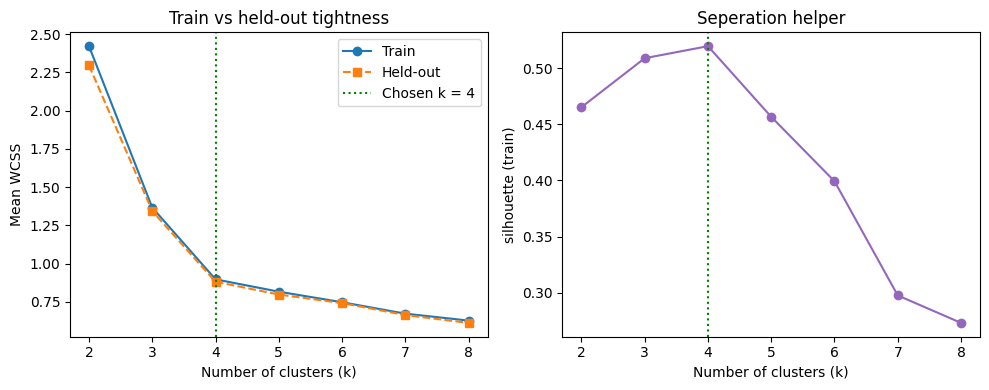

In [37]:
fig, axes = plt.subplots(1,2, figsize=(10,4))

axes[0].plot(k_report["k"], k_report["train_mean_wcss"],"o-",label="Train")
axes[0].plot(k_report["k"], k_report["holdout_mean_wcss"],"s--",label="Held-out")
axes[0].axvline(4,color="green",linestyle=":",label="Chosen k = 4")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Mean WCSS")
axes[0].set_title("Train vs held-out tightness")
axes[0].set_xticks(list(k_values))
axes[0].legend()

axes[1].plot(k_report["k"], k_report["silhouette"],"o-",color="tab:purple")
axes[1].axvline(4, color="green", linestyle=":")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("silhouette (train)")
axes[1].set_title("Seperation helper")
axes[1].set_xticks(list(k_values))

fig.tight_layout()
plt.show()


In [33]:
CHOSEN_K = 4

production_scaler = StandardScaler()
X_scaled = production_scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=CHOSEN_K,
    init="k-means++",
    n_init=10,
    random_state=42,
)

kmeans.fit(X_scaled)

print("Iteration to converge : ",kmeans.n_iter_)
print("Inertia (WCSS) on all customers: ",round(kmeans.inertia_,1))
print("Mean WCSS: ",round(kmeans.inertia_/len(X_scaled),3))

Iteration to converge :  4
Inertia (WCSS) on all customers:  1068.1
Mean WCSS:  0.89


Inference

In [44]:
new_customer = pd.DataFrame([
    {
        "visits_last_year":3,
        "avg_order_value":310.0,
        "days_since_purchase":80,
        "online_order_share":0.30,
        "promo_emails_opened":2
    }
])

scaled_new = production_scaler.transform(new_customer)

new_cluster = kmeans.predict(scaled_new)[0]

print(new_cluster)


3
